In [264]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [265]:
df = pd.read_csv(
    "data/sve.csv"
)


df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    "Date"
)


# log return target
df["EURUSD_Return"] = np.log(
    df["EURUSD"] /
    df["EURUSD"].shift(1)
)


df.dropna(inplace=True)

df.reset_index(drop=True,inplace=True)


df.head()

,Date,CPI,HICP,GER2Y,GER10Y,USA2Y,USA10Y,EURUSD,EURUSD_Return
0,1999-01-02,164.7,57.07,3.071,3.863,4.575,4.677,1.1680,0.000000
1,1999-01-03,164.7,57.07,3.071,3.863,4.575,4.677,1.1680,0.000000
2,1999-01-04,164.7,57.07,3.071,3.748,4.575,4.677,1.1812,0.011238
3,1999-01-05,164.7,57.07,3.089,3.791,4.641,4.745,1.1755,-0.004837
4,1999-01-06,164.7,57.07,3.051,3.768,4.591,4.709,1.1625,-0.011121


In [266]:
features = [
    #"CPI",
    #"HICP",
    #"GER2Y",
    #"GER10Y",
    #"USA2Y",
    #"USA10Y",
    "EURUSD"
]
br_prom = min(len(features), 4)

target = "EURUSD_Return"



X_raw = df[features].values

y_raw = df[target].values.reshape(-1,1)

In [267]:
n = len(df)


train_end = int(n*0.7)

val_end = int(n*0.85)


print(train_end)
print(val_end)

7009
8511


In [268]:
feature_scaler = StandardScaler()

target_scaler = StandardScaler()



feature_scaler.fit(
    X_raw[:train_end]
)


target_scaler.fit(
    y_raw[:train_end]
)



X_scaled = feature_scaler.transform(
    X_raw
)


y_scaled = target_scaler.transform(
    y_raw
)

In [269]:
pca = PCA(
    n_components=br_prom
)


pca.fit(
    X_scaled[:train_end]
)


X_pca = pca.transform(
    X_scaled
)


print(
    pca.explained_variance_ratio_
)


print(
    "Total variance:",
    np.sum(
        pca.explained_variance_ratio_
    )
)

[1.]
Total variance: 1.0


In [270]:
WINDOW = 90



def create_sequences(
    X,
    y,
    window
):

    Xs=[]
    ys=[]

    for i in range(window,len(X)):

        Xs.append(
            X[i-window:i]
        )

        ys.append(
            y[i]
        )


    return np.array(Xs),np.array(ys)



X,y = create_sequences(
    X_pca,
    y_scaled,
    WINDOW
)


print(X.shape)
print(y.shape)

(9923, 90, 1)
(9923, 1)


In [271]:
train_split = int(len(X)*0.7)

val_split = int(len(X)*0.85)



X_train = X[:train_split]
y_train = y[:train_split]


X_val = X[train_split:val_split]
y_val = y[train_split:val_split]


X_test = X[val_split:]
y_test = y[val_split:]

In [272]:
model = Sequential([
    LSTM(1024, input_shape=(WINDOW, X_train.shape[2])),
    Dense(64, activation="relu"),
    Dense(1)
])


model.summary()

c:\Users\Aca\Desktop\Petnica\Mentorski rad\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1024)           │     4,202,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,268,161 (16.28 MB)

 Trainable params: 4,268,161 (16.28 MB)

 Non-trainable params: 0 (0.00 B)

In [273]:
model.compile(

    optimizer=Adam(
        learning_rate=0.0005
    ),

    loss="mse",

    metrics=["mae"]

)

In [274]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)



history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=1,

    batch_size=64,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

109/109 ━━━━━━━━━━━━━━━━━━━━ 75s 677ms/step - loss: 1.0072 - mae: 0.6646 - val_loss: 0.4863 - val_mae: 0.4639 - learning_rate: 5.0000e-04


In [275]:
pred_scaled = model.predict(
    X_test
)


pred_return = target_scaler.inverse_transform(
    pred_scaled
)
print(pred_scaled.min(), pred_scaled.max())
print(pred_scaled.mean(), pred_scaled.std())

print(pred_return.min(), pred_return.max())
print(pred_return.mean(), pred_return.std())

actual_return = target_scaler.inverse_transform(
    y_test
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step
-0.005615549 0.003430903
0.00028678897 0.0012830659
-2.2526645e-05 2.5781495e-05
8.991898e-06 6.8515837e-06


In [276]:
start_price = df["EURUSD"].iloc[
    val_split + WINDOW
]

In [277]:
# Flatten and use float64 for better numerical precision
pred_return = pred_return.ravel().astype(np.float64)
actual_return = actual_return.ravel().astype(np.float64)

# Initial log-price
log_start_price = np.log(start_price)

# Accumulate log-prices
log_pred_price = log_start_price + np.cumsum(pred_return)
log_actual_price = log_start_price + np.cumsum(actual_return)

# Convert back to prices
pred_price = np.exp(log_pred_price)
actual_price = np.exp(log_actual_price)

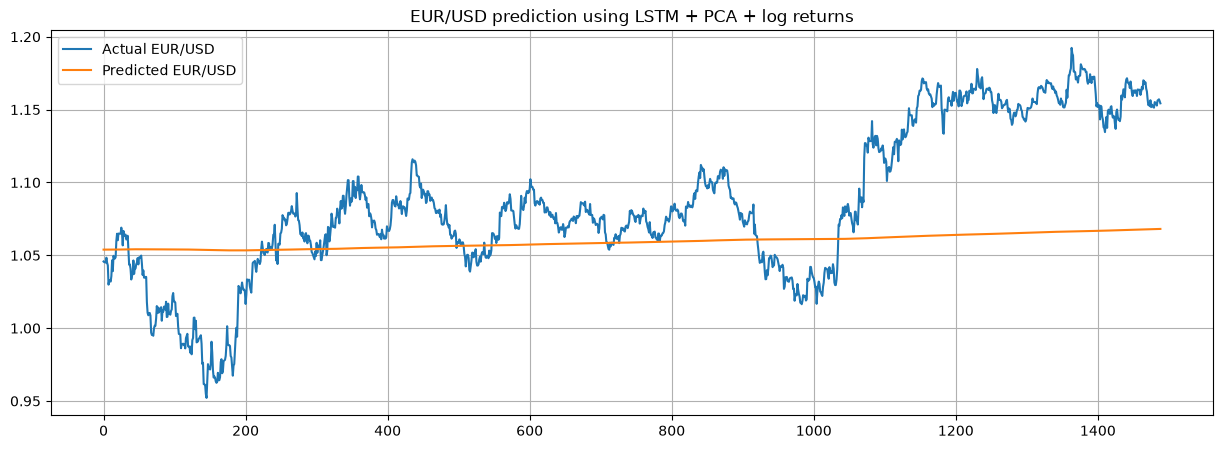

In [278]:
plt.figure(figsize=(15,5))


plt.plot(
    actual_price,
    label="Actual EUR/USD"
)


plt.plot(
    pred_price,
    label="Predicted EUR/USD"
)


plt.legend()

plt.grid()

plt.title(
    "EUR/USD prediction using LSTM + PCA + log returns"
)


plt.show()

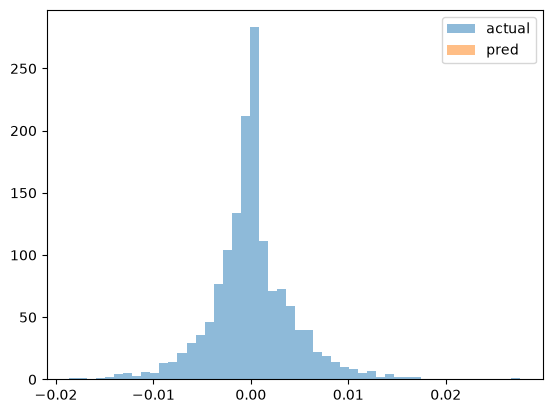

In [279]:
plt.hist(actual_return, bins=50, alpha=0.5, label="actual")
plt.hist(pred_return, bins=50, alpha=0.5, label="pred")
plt.legend()

In [280]:
print("Predicted returns:")
print(pred_return[:20])

print("Mean:", pred_return.mean())
print("Std :", pred_return.std())

print("Actual mean:", actual_return.mean())
print("Actual std :", actual_return.std())

Predicted returns:
[4.92281742e-07 3.21942935e-08 9.68170752e-08 4.28981821e-07
 8.04623141e-07 1.51415952e-06 1.65433630e-06 1.76539925e-06
 7.13055215e-07 7.07146683e-07 5.83252586e-07 2.46960099e-07
 2.92634468e-07 1.21839912e-06 8.44568149e-07 1.98012503e-06
 2.55370242e-06 3.22095639e-06 4.03006788e-06 5.82987468e-06]
Mean: 8.991897047785858e-06
Std : 6.851583483344007e-06
Actual mean: 6.11170572399307e-05
Actual std : 0.004252703498006942


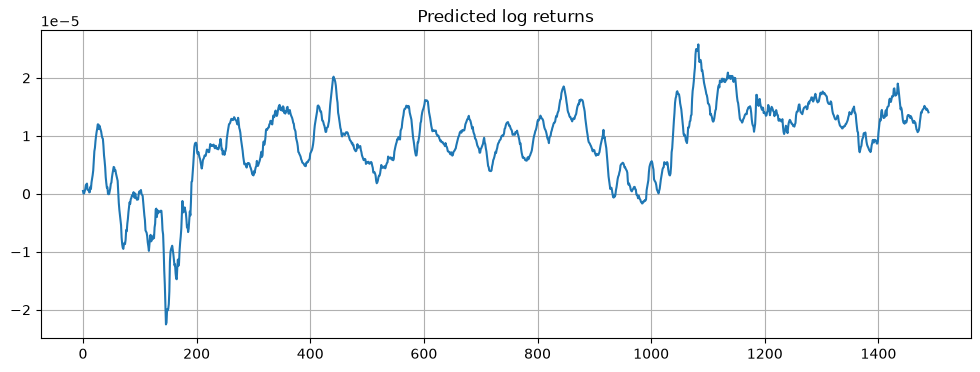

In [281]:
plt.figure(figsize=(12,4))
plt.plot(pred_return)
plt.title("Predicted log returns")
plt.grid()